In [4]:
import pandas as pd

df =  pd.read_csv('PID_Trail_1.csv')

In [5]:
df.head()

,Time(ms),Setpoint,Angle,ControlVoltage,PWM,Error,Integral,Derivative
0,20,180.0,0.00,7.52,159,180.00,3.60,9000.00
1,40,180.0,1.41,7.79,165,178.59,7.17,-70.59
2,60,180.0,4.59,7.98,169,175.41,10.68,-158.82
3,80,180.0,9.88,8.07,171,170.12,14.08,-264.71
4,100,180.0,16.24,8.11,172,163.76,17.36,-317.65


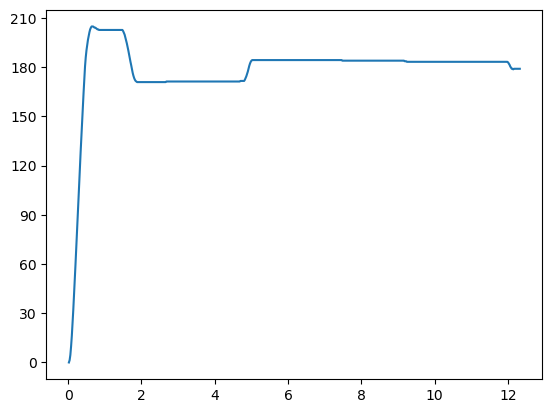

In [11]:
import matplotlib.pyplot as plt

time = df['Time(ms)']/1000
angle = df['Angle']

plt.plot(time, angle)
plt.yticks([angle for angle in range(0,240,30)])
plt.show()

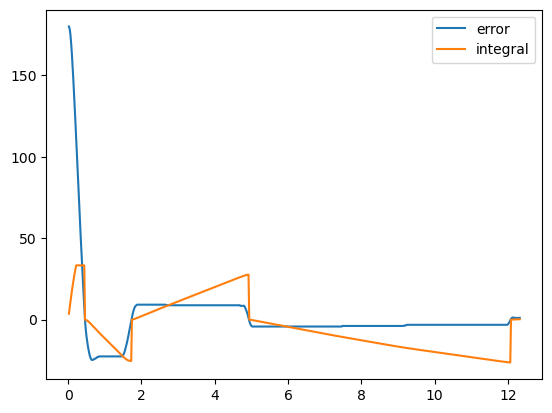

In [15]:
plt.plot(time, df['Error'], label='error')
plt.plot(time, df['Integral'], label='integral')
#plt.plot(time, df['Derivative'], label='derivative')
plt.legend()
plt.show()


## error and integral Analysis
We can see the time from 2~5 the controller sees the error but takes time to accumate enough voltage to overcome static friction, so in order to shorten this time I can add 2.5 volts which is enough to overcome static friction in the 25GA-370 130RPM motor.

## Successful Tuning Results

In [16]:
df_30_deg = pd.read_csv('PID_Success_30_Deg.csv')
df_180_deg = pd.read_csv('PID_Success_180_Deg.csv')
df_360_deg = pd.read_csv('PID_Success_360_Deg.csv')

In [ ]:
time = df_30_deg['Time(ms)']/1000
angle = df['Angle']

fig,ax = plt.subplots(1,3)

plt.plot(time, angle)
plt.yticks([angle for angle in range(0,240,30)])
plt.show()

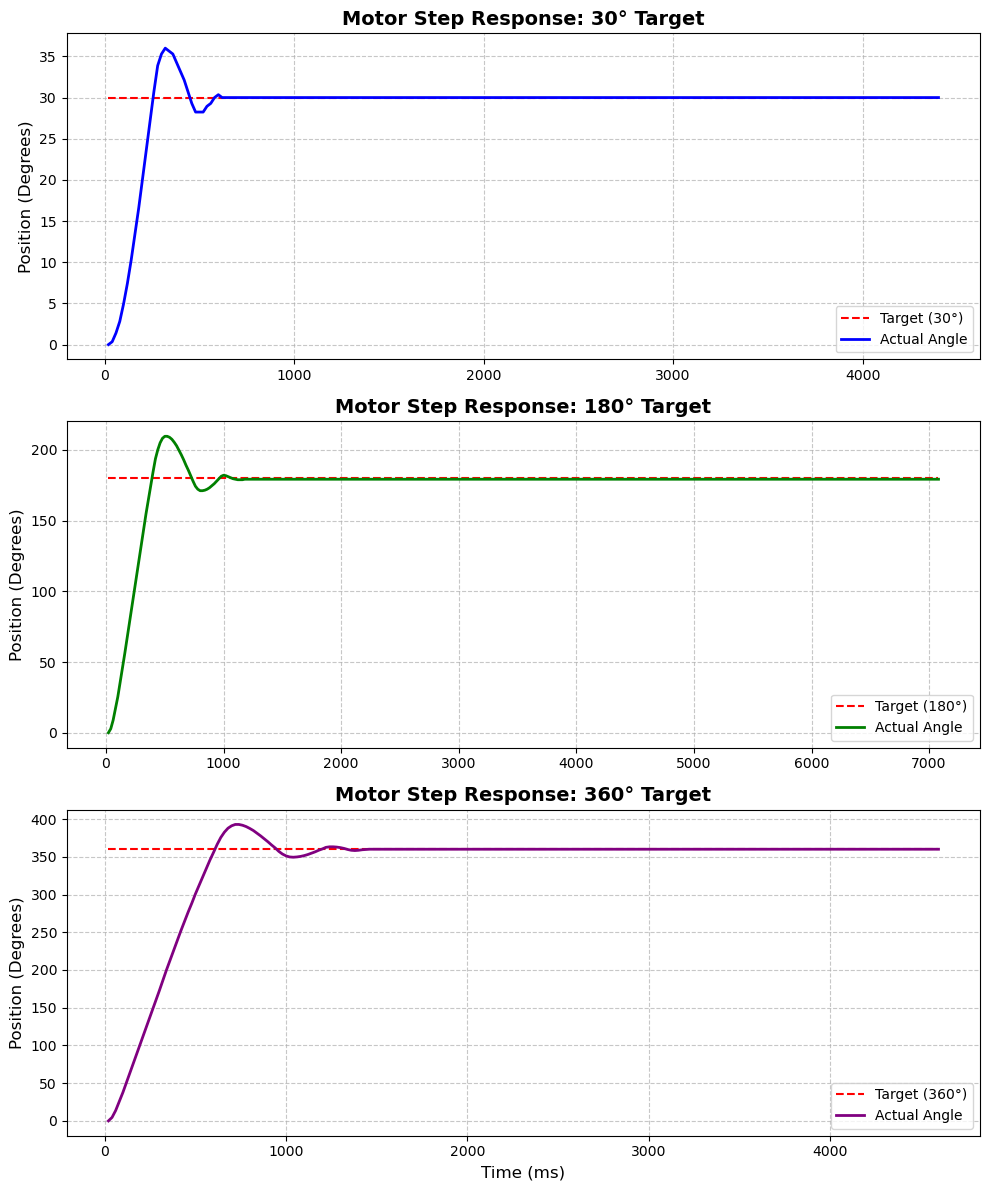

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Read the Data ---
df_30_deg = pd.read_csv('PID_Success_30_Deg.csv')
df_180_deg = pd.read_csv('PID_Success_180_Deg.csv')
df_360_deg = pd.read_csv('PID_Success_360_Deg.csv')

# --- Create the Subplots (3 rows, 1 column) ---
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# --- 1. Plot 30 Degree Response ---
axes[0].plot(df_30_deg['Time(ms)'], df_30_deg['Setpoint'], 'r--', label='Target (30°)')
axes[0].plot(df_30_deg['Time(ms)'], df_30_deg['Angle'], 'b-', linewidth=2, label='Actual Angle')
axes[0].set_title('Motor Step Response: 30° Target', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Position (Degrees)', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.7)

# --- 2. Plot 180 Degree Response ---
axes[1].plot(df_180_deg['Time(ms)'], df_180_deg['Setpoint'], 'r--', label='Target (180°)')
axes[1].plot(df_180_deg['Time(ms)'], df_180_deg['Angle'], 'g-', linewidth=2, label='Actual Angle')
axes[1].set_title('Motor Step Response: 180° Target', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Position (Degrees)', fontsize=12)
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.7)

# --- 3. Plot 360 Degree Response ---
axes[2].plot(df_360_deg['Time(ms)'], df_360_deg['Setpoint'], 'r--', label='Target (360°)')
axes[2].plot(df_360_deg['Time(ms)'], df_360_deg['Angle'], 'purple', linewidth=2, label='Actual Angle')
axes[2].set_title('Motor Step Response: 360° Target', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time (ms)', fontsize=12)
axes[2].set_ylabel('Position (Degrees)', fontsize=12)
axes[2].legend(loc='lower right')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()